In [13]:
import pandas as pd
from itertools import combinations

# load raw festival dataset
fest_data = pd.read_csv("festival_project_artists.csv")

# clean artist names (remove extra spaces)
fest_data["artist_clean"] = fest_data["artist_clean"].str.strip()

pairs = []

# group by festival and create artist pairs
for festival, group in fest_data.groupby("festival"):
    
    artists = group["artist_clean"].unique()
    
# generate all possible artist pairs

    for pair in combinations(artists, 2):
        pairs.append(tuple(sorted(pair)))

# convert pairs into dataframe
paired_artists = pd.DataFrame(pairs, columns=["artist1", "artist2"])


# count co-appearances
coop_network = (paired_artists.groupby(["artist1", "artist2"]).size().reset_index(name="coappearances"))

# save dataset for network step
coop_network.to_csv("artist_network.csv", index=False)

print(coop_network.head())

  artist1   artist2  coappearances
0    $ami  33 Below              1
1    $ami     6ejou              1
2    $ami      AHEE              1
3    $ami  ALLEYCVT              1
4    $ami     AMÉMÉ              1


In [14]:
# load processed network data
df = pd.read_csv("artist_network.csv")

In [15]:
import networkx as nx

# create graph from edge list
G_full = nx.from_pandas_edgelist(
    df,
    source="artist1",
    target="artist2",
    edge_attr="coappearances"
)

print("Artists:", G_full.number_of_nodes())
print("Connections:", G_full.number_of_edges())

Artists: 977
Connections: 122941


In [16]:
# calculate weighted degree (connection strength)
weighted_degree = dict(G_full.degree(weight="coappearances"))

# convert to dataframe
weighted_degree_df = pd.DataFrame(
    weighted_degree.items(),
    columns=["artist", "weighted_degree"]
)

# sort from highest to lowest
weighted_degree_df = weighted_degree_df.sort_values(
    "weighted_degree",
    ascending=False
)

# save to csv
weighted_degree_df.to_csv("weighted_degree_artists.csv", index=False)

# preview top 10
print("\nTop connected artists (weighted degree):")
print(weighted_degree_df.head(10))


Top connected artists (weighted degree):
                      artist  weighted_degree
132                  Fcukers             1000
337                   Tape B              937
201                   Levity              758
121                Dom Dolla              741
305              Sara Landry              735
163  Interplanetary Criminal              731
230                    Mau P              708
81            Chase & Status              708
368                      YDG              693
92                  Crankdat              693


In [17]:
# weighted degree = total connection strength
weighted_degree = dict(G_full.degree(weight="coappearances"))

# betweenness = identifies bridge artists
k = min(100, G_full.number_of_nodes())
betweenness = nx.betweenness_centrality(G_full, k=k, seed=42)

# convert to dataframe
betweenness_df = pd.DataFrame(betweenness.items(), columns=["artist", "betweenness"])

# round betweenness score
betweenness_df["betweenness"] = betweenness_df["betweenness"].round(4)


# create a dictionary showing which festivals each artist appeared in
artist_festivals = {}

for artist, group in fest_data.groupby("artist_clean"):
    festivals = group["festival"].dropna()
    unique_festivals = sorted(set(festivals))

    artist_festivals[artist] = unique_festivals


# create empty lists for the new columns
festival_names_list = []
num_festivals_list = []

for artist in betweenness_df["artist"]:
    festivals = artist_festivals[artist]

    festival_names = ", ".join(festivals)
    num_festivals = len(festivals)

    festival_names_list.append(festival_names)
    num_festivals_list.append(num_festivals)


# add new columns to betweenness dataframe
betweenness_df["num_festivals"] = num_festivals_list
betweenness_df["festival_names"] = festival_names_list


# sort by highest betweenness first
betweenness_df = betweenness_df.sort_values("betweenness", ascending=False)


# save
betweenness_df.to_csv("bridge_artists.csv", index=False)

betweenness_df.head(10)

,artist,betweenness,num_festivals,festival_names
132,Fcukers,0.0345,6,"Coachella, EDC, Electric Forest, Hard Summer, ..."
337,Tape B,0.0335,6,"Bonnaroo, EDC, Electric Forest, Hard Summer, L..."
163,Interplanetary Criminal,0.0236,4,"Coachella, EDC, Electric Forest, Lightning in ..."
201,Levity,0.0187,4,"Bonnaroo, EDC, Lollapalooza, Outside Lands"
134,Francis Mercier,0.0184,3,"Coachella, EDC, Lightning in a Bottle"
81,Chase & Status,0.0166,3,"Coachella, EDC, Lollapalooza"
230,Mau P,0.0164,3,"Coachella, EDC, Lollapalooza"
121,Dom Dolla,0.0159,4,"Bonnaroo, EDC, Hard Summer, Lollapalooza"
305,Sara Landry,0.0147,4,"Coachella, EDC, Electric Forest, Hard Summer"
459,Sammy Virji,0.0131,5,"Bonnaroo, Coachella, Lightning in a Bottle, Lo..."



Drawing graph for coappearances >= 2


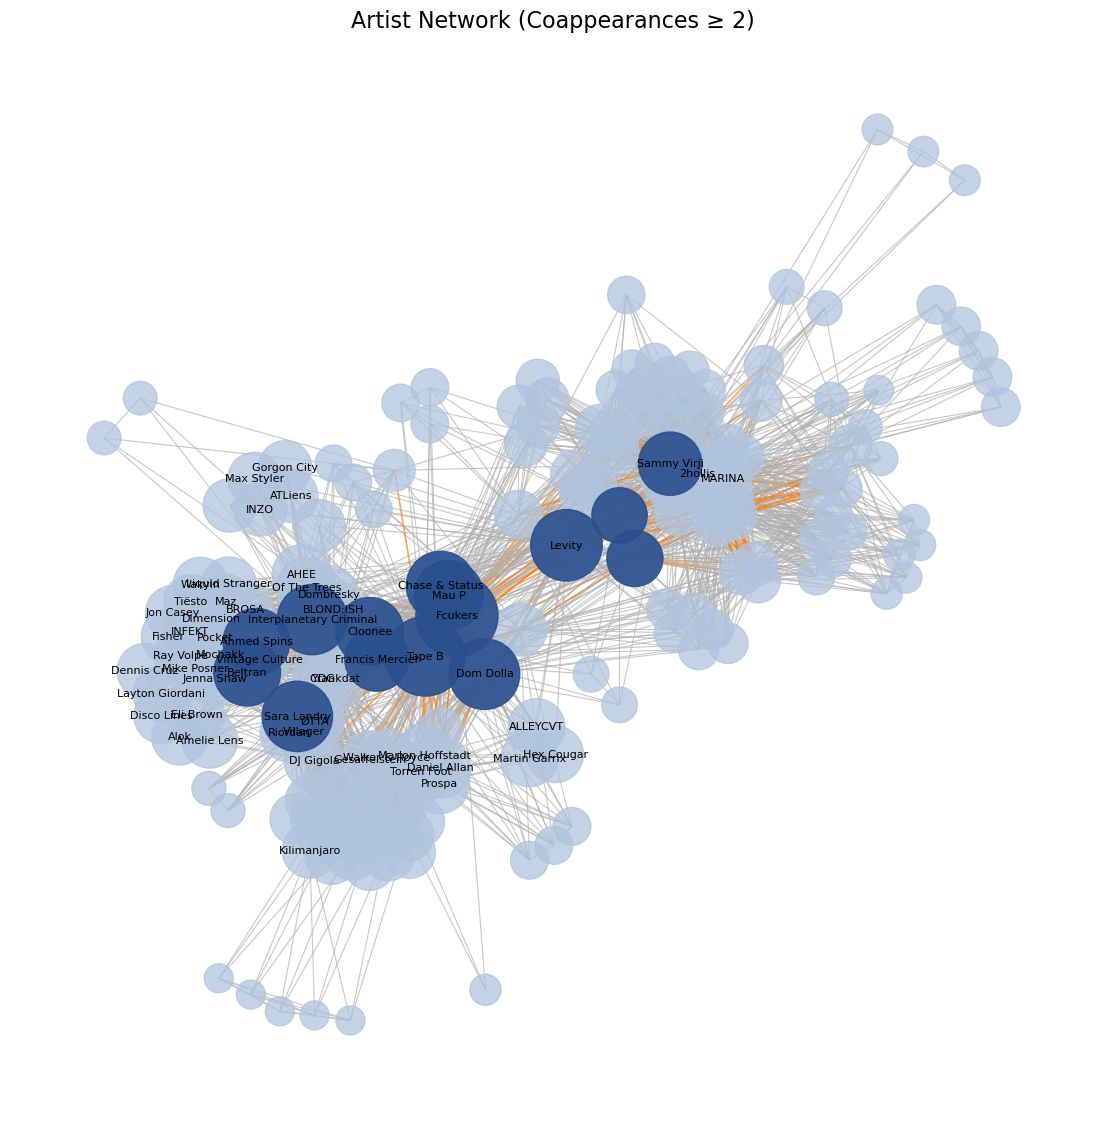


Drawing graph for coappearances >= 3


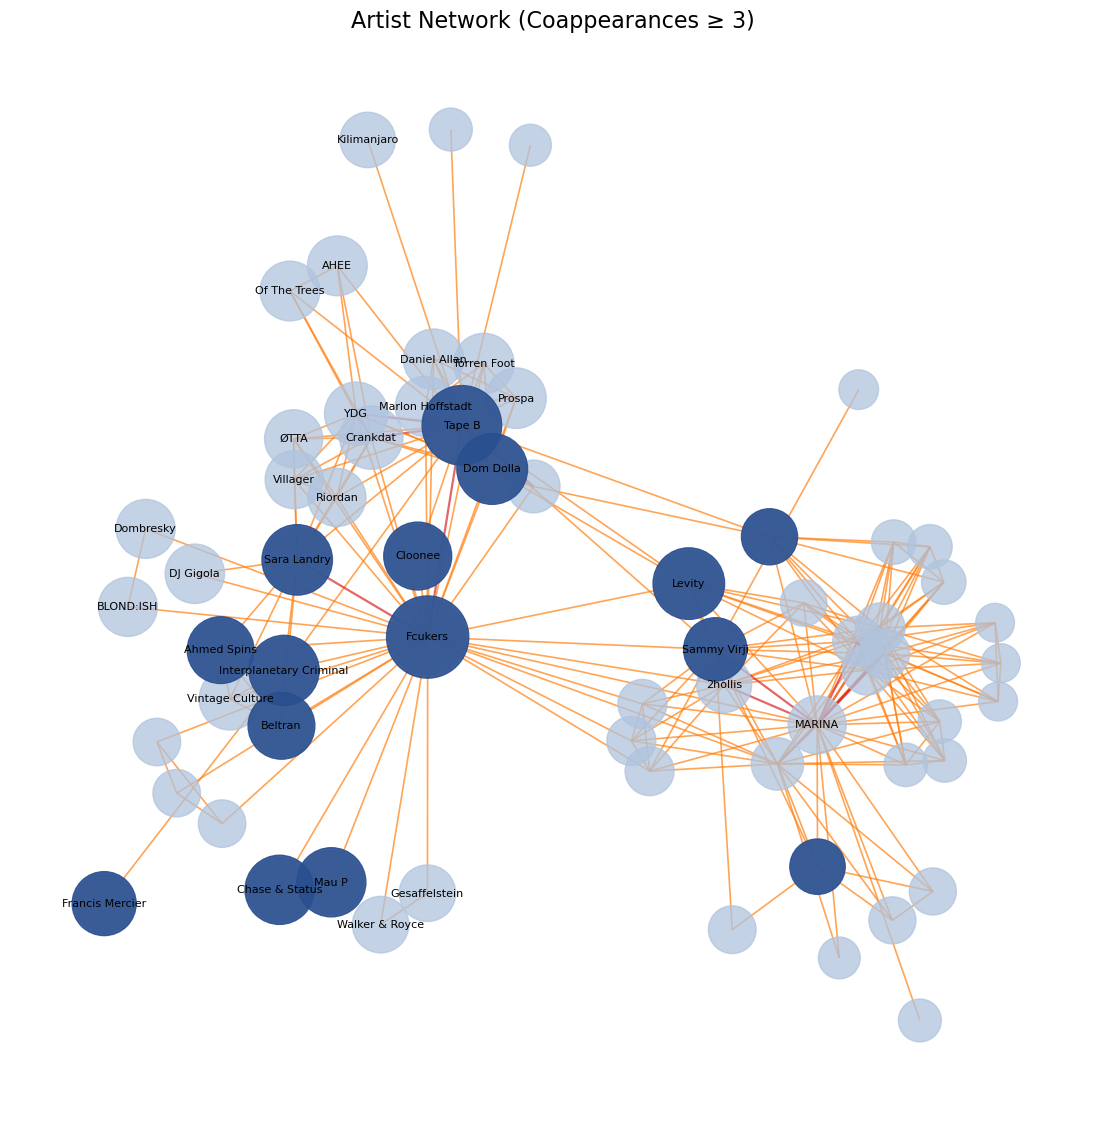


Drawing graph for coappearances >= 4


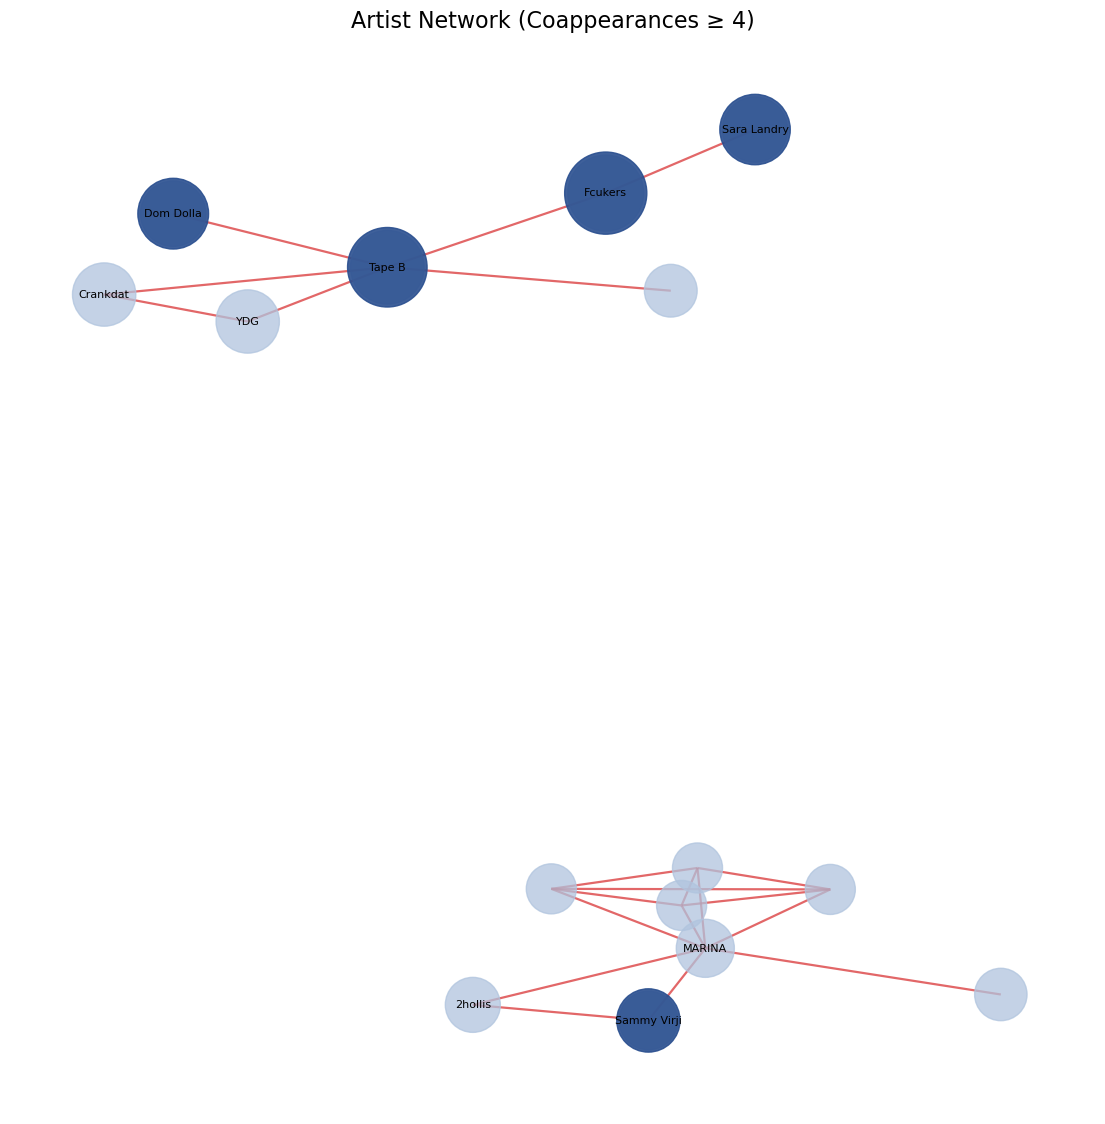

In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# loop through different thresholds
for threshold in [2, 3, 4]:
    
    print(f"\nDrawing graph for coappearances >= {threshold}")
    
    G_vis = nx.Graph()

    # filter edges for visualization only
    for u, v, data in G_full.edges(data=True):
        if data["coappearances"] >= threshold:
            G_vis.add_edge(u, v, coappearances=data["coappearances"])

    # skip if empty
    if G_vis.number_of_edges() == 0:
        print(f"No edges for threshold {threshold}")
        continue

    # node size based on importance (full graph)
    node_sizes = [max(weighted_degree.get(n, 1) * 3, 30) for n in G_vis.nodes()]

    # get edge weights
    edge_weights = [G_vis[u][v]["coappearances"] for u, v in G_vis.edges()]

    # scale edge thickness
    edge_widths = [max(w * 0.4, 0.8) for w in edge_weights]

    # assign colors based on coappearance level
    edge_colors = []
    for w in edge_weights:
        if w == 2:
            edge_colors.append("#b0b0b0")  # light gray (weak)
        elif w == 3:
            edge_colors.append("#ff7f0e")  # orange (medium)
        else:
            edge_colors.append("#d62728")  # red (strong)

    # layout
    pos = nx.spring_layout(G_vis, k=0.2, seed=42)

    fig, ax = plt.subplots(figsize=(14, 14))

    # draw nodes
    nx.draw_networkx_nodes(
        G_vis,
        pos,
        node_size=node_sizes,
        node_color="lightsteelblue",
        alpha=0.75,
        ax=ax
    )

    # highlight top bridge artists
    top_bridge = [
        n for n in betweenness_df.head(15)["artist"]
        if n in G_vis.nodes()
    ]

    nx.draw_networkx_nodes(
    G_vis,
    pos,
    nodelist=top_bridge,
    node_size=[weighted_degree[n] * 3.5 for n in top_bridge],
    node_color="#2a4f8f",  # dark blue
    alpha=0.9,
    ax=ax
    )
    
    # draw edges
    nx.draw_networkx_edges(
        G_vis,
        pos,
        width=edge_widths,
        edge_color=edge_colors,
        alpha=0.7,
        ax=ax
    )

    # label top connected artists
    top_labels = sorted(weighted_degree, key=weighted_degree.get, reverse=True)[:60]
    labels = {n: n for n in top_labels if n in G_vis.nodes()}

    nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8, ax=ax)

    # title and save
    ax.set_title(f"Artist Network (Coappearances ≥ {threshold})", fontsize=16)
    ax.axis("off")

    filename = f"artist_network_threshold_{threshold}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()